## Imbalanced Learning

Przypadki, w których badane klasy są starannie wyważone, są raczej wyjątkiem niż regułą. W większości interesujących problemów, z którymi się zetkniemy, klasy są skrajnie niezrównoważone. Na szczęście niewielka część płatności internetowych to oszustwa, podobnie jak niewielka część populacji zapada na rzadkie choroby. I odwrotnie, niewielu graczy wygrywa na loterii, a mniejszość znajomych jest naszymi bliskimi przyjaciółmi. Zwykle interesuje nas uchwycenie tych rzadkich przypadków.

### Przykład niezbalansowanych danych
Generowanie danych

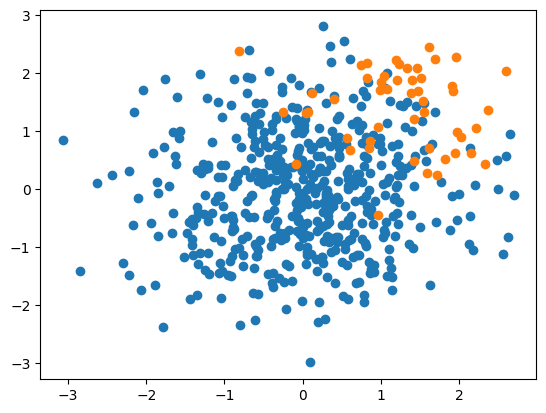

In [3]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1984)

group1_x = np.random.normal(0, 1, 500) 
group1_y = np.random.normal(0, 1, 500) 
group2_x = np.random.normal(1.3, 0.75, 50) 
group2_y = np.random.normal(1.3, 0.75, 50) 

X = np.concatenate((np.concatenate((group1_x[:, np.newaxis], group1_y[:, np.newaxis]), axis=1), 
                    np.concatenate((group2_x[:, np.newaxis], group2_y[:, np.newaxis]), axis=1)), axis=0)
y = np.concatenate((np.zeros(500), np.ones(50)))
# rysowanie grup
plt.scatter(group1_x, group1_y)
plt.scatter(group2_x, group2_y)

plt.show()


Tworzenie modelu SVM

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [4]:
from sklearn import svm

clf = svm.SVC(kernel='linear')
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_
print('w = ', w, ' b = ',b)

w =  [0.90322043 0.98052706]  b =  [-2.73040794]


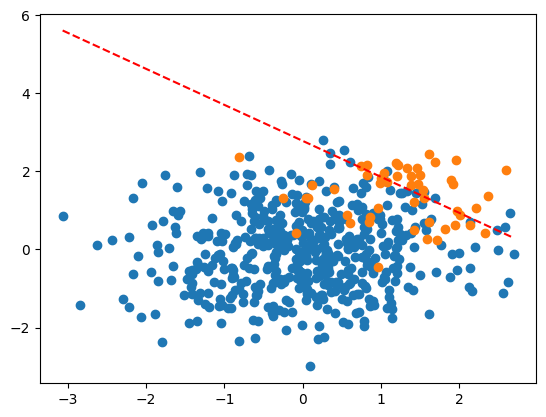

In [5]:
plt.scatter(group1_x, group1_y)
plt.scatter(group2_x, group2_y)

x_min = np.min(X[:, 0])
x_max = np.max(X[:, 0])
y_min = np.min(X[:, 1])
y_max = np.max(X[:, 1])
x_plot = np.linspace(x_min, x_max, 2)
y_plot = -w[0] / w[1] * x_plot - b / w[1]
plt.plot(x_plot, y_plot, 'r--')

plt.show()

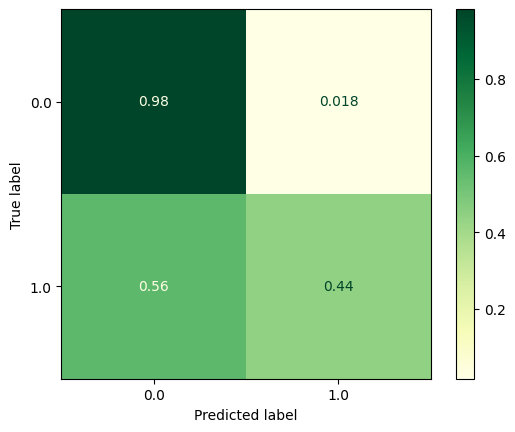

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clf, X, y, cmap='YlGn', normalize = 'true')
plt.show()

In [7]:
y_pred = clf.predict(X)
accuracy_score(y,y_pred)

0.9327272727272727

## Over-sampling

### Naiwny Over-sampling

Jednym ze sposobów walki z tym problemem jest generowanie nowych próbek w klasach, które są niedostatecznie reprezentowane. Najbardziej naiwną strategią jest generowanie nowych wierszy poprzez losowanie ze zwracaniem spośród istniejących wierszy przy pomocy **RandomOverSampler**

#### Bez balansowania 

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score

df = pd.read_csv('diabetes.csv')

X = df.drop(columns='Outcome')
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# las losowy
rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train,y_train)

print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8181818181818182
Recall: 0.6808510638297872


#### Z balansowaniem

https://imbalanced-learn.org/stable/user_guide.html

In [9]:
from imblearn.over_sampling import RandomOverSampler


sampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8116883116883117
Recall: 0.723404255319149


### SMOTE - Synthetic Minority Oversampling Technique 
### ADASYN - Adaptive Synthetic

In [10]:
from imblearn.over_sampling import SMOTE

sampler = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8181818181818182
Recall: 0.7659574468085106


In [11]:
from imblearn.over_sampling import ADASYN

sampler = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.7922077922077922
Recall: 0.7446808510638298


Istnieją warianty SMOTE - BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, SMOTENC(rozszerzenie algorytmu SMOTE, dla którego dane kategoryczne są traktowane inaczej), SMOTEN (jeśli są tylko z dane kategoryczne) 



Zarówno SMOTE, jak i ADASYN używają tego samego algorytmu do generowania nowych wierszy. Mając wiersz $x_i$, nowy $x_{\text {new }}$ zostanie wygenerowany z uwzględnieniem jego $k$ najbliższych sąsiadów. Następnie wybierany jest jeden z tych najbliższych sąsiadów $x_{z i}$ i generowana jest próbka w następujący sposób:
$$
x_{\text {new }}=x_i+\lambda\left(x_{z i}-x_i\right)
$$
gdzie $\lambda$ jest liczbą losową z zakresu $[0,1]$. Ta interpolacja utworzy wiersz pomiędzy $x_i$ a $x_{z i}$.

SMOTE-NC nieznacznie zmienia sposób generowania nowego wiersza inaczej traktując cechy kategoryczne. O kategoriach nowo wygenerowanego wiersza decyduje najczęstsza kategoria spośród najbliższych sąsiadów.

Inne warianty SMOTE i ADASYN różnią się od siebie tym, jak wybierają wiersze $x_i$ przed wygenerowaniem nowych próbek.

Zwykły algorytm SMOTE losuje wszystkie dostępne wiersze $x_i$ z jednakowym prawdopodobieństwem.

ADASYN działa podobnie do zwykłego SMOTE. Jednak liczba wierszy generowanych dla każdego $x_i$ jest proporcjonalna do liczby wierszy, które nie należą do tej samej klasy co $x_i$ w danym sąsiedztwie. W związku z tym więcej próbek zostanie wygenerowanych w obszarze, w którym w najbliższym sąsiedztwie klasy są mniej jednorodne. Parametr n_neighbors=5 w SMOTE i ADASYN.

## Under-sampling

#### Generowanie prototypów
Niech $S$ będzie zbiorem danych. Algorytmy generowania prototypów wygenerują nowy zbiór $S^{\prime}$ gdzie $\left|S^{\prime}\right|<|S|$ i $S^{\prime} \not \subset S$. Innymi słowy, technika generowania prototypów zmniejszy liczbę próbek w klasach, ale pozostałe próbki zostaną wygenerowane — a nie wybrane z oryginalnego zestawu.

**ClusterCentroids** wykorzystuje metodę $k$-średnich do zmniejszenia liczby próbek. Dlatego każda klasa zostanie zsyntetyzowana za pomocą centroidów metody $k$-średnich zamiast oryginalnych próbek.

In [12]:
from imblearn.under_sampling import ClusterCentroids

sampler = ClusterCentroids(random_state=0)

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8311688311688312
Recall: 0.851063829787234


#### Wybór prototypu
W przeciwieństwie do algorytmów generowania prototypów, algorytmy selekcji prototypów wybiorą próbki z oryginalnego zbioru $S$. Dlatego $S^{\prime}$ jest zdefiniowany tak, jak $\left|S^{\prime}\right|<|S|$ i $S^{\prime} \subset S$.

Ponadto algorytmy te można podzielić na dwie grupy: (i) techniki kontrolowanego niedopróbkowania oraz (ii) czyszczące techniki niedopróbkowania. Pierwsza grupa metod pozwala na strategię niedopróbkowania, w której liczba próbek w $S^{\prime}$ jest określana przez użytkownika. Z drugiej strony techniki czyszczenia podpróbkowania nie pozwalają na tę specyfikację.

### Controlled under-sampling

#### RandomUnderSampler

In [13]:
from imblearn.under_sampling import RandomUnderSampler
sampler = RandomUnderSampler(random_state=0)#,replacement=True)

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8051948051948052
Recall: 0.8297872340425532


### NearMiss

**NearMiss** dodaje reguły heurystyczne do wybierania próbek - implementuje 3 różne typy heurystyki, które można wybrać za pomocą parametru **version**

In [14]:
from imblearn.under_sampling import NearMiss
sampler = NearMiss(version=1) ## na prezentacji zmienić na 2, a potem 3

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.7597402597402597
Recall: 0.8297872340425532


Niech wiersze pozytywne będą tymi należącymi do klasy, która ma zostać zredukowana. Wiersz ujemny odnosi się do tych z klasy mniejszościowej, niedoreprezentowanej.

* NearMiss-1 wybiera wiersze dodatnie, dla których średnia odległość do $N$ najbliższych wierszy ujemnych jest najmniejsza (domyślnie n_neighbors=3).
* NearMiss-2 wybiera te wiersze dodatnie, dla których średnia odległość do $N$ najdalszych wierszy ujemnych jest najmniejsza (domyślnie n_neighbors=3).
* NearMiss-3 to algorytm dwuetapowy. Po pierwsze, dla każdej negatywnego wiersza zachowani zostaną ich najbliżsi sąsiedzi $M$ (domyślnie n_neighbors_ver3=3). Następnie wybiera te pozytywne wiersze, dla których średnia odległość do najbliższych sąsiadów $N$ jest największa (domyślnie n_neighbors=3).

### Cleaning under-sampling

#### Tomek’s links

Łączenie Tomka między dwiema wierszami różnych klas $x$ i $y$ jest zdefiniowane tak, że dla dowolnej próbki $z$ :
$$
d(x, y)<d(x, z) \text { i } d(x, y)<d(y, z).
$$
Innymi słowy, łączenie Tomka istnieje, jeśli dwie próbki są najbliższymi sąsiadami.

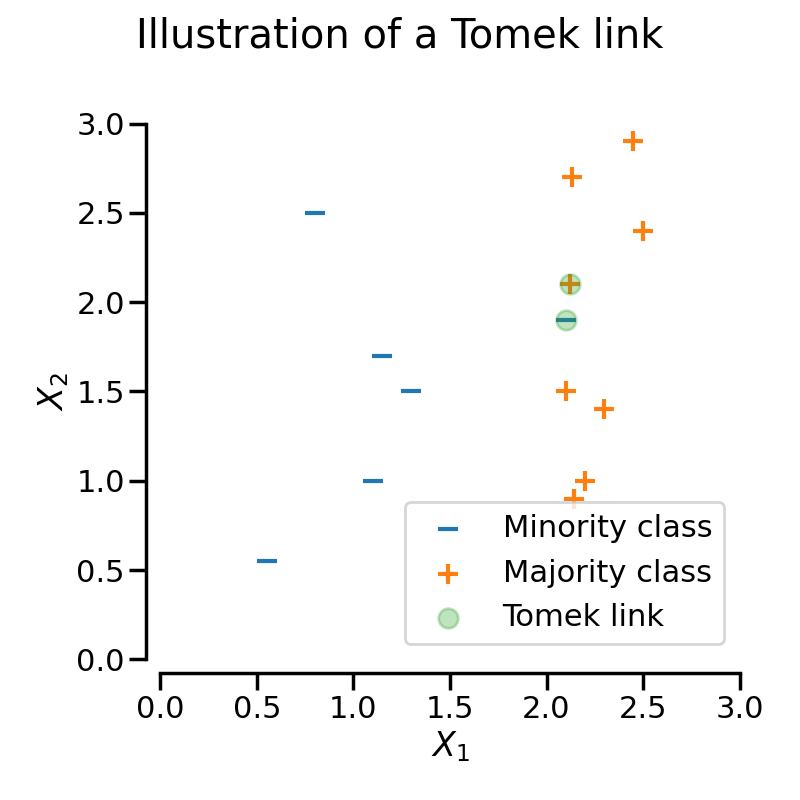

Parametr **sampling_strategy** kontroluje, która część łączenia zostanie usunięta. Na przykład ustawienie domyślne (tj. sampling_strategy='auto') usunie wiersz z klasy większościowej. Całe łączenie można usunąć, ustawiając parametr sampling_strategy na 'all'. 

In [15]:
from imblearn.under_sampling import TomekLinks
sampler = TomekLinks()#sampling_strategy='all') 

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.7987012987012987
Recall: 0.7446808510638298


Inne metody: EditedNearestNeighbours, RepeatedEditedNearestNeighbours, AllKNN, CondensedNearestNeighbour,  OneSidedSelection, NeighbourhoodCleaningRule, InstanceHardnessThreshold 

### Kombinacja over- and under-samplingu

Okazuje się, że SMOTE może generować zanieczyszczenia poprzez interpolację nowych punktów między wartościami odstającymi i wartościami wewnętrznymi. Ten problem można rozwiązać, czyszcząc przestrzeń powstałą z nadpróbkowania.

TomekLinks i EditedNearestNeighbours to dwie metody czyszczenia, które używa się po zastosowaniu nadpróbkowania SMOTE w celu uzyskania czystszej przestrzeni. Dwa gotowe narzędzia : SMOTETomek oraz (ii) SMOTEENN.

In [16]:
from imblearn.combine import SMOTEENN, SMOTETomek
sampler = SMOTEENN(random_state=0) #SMOTETomek(random_state=0) #

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train_resampled,y_train_resampled)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.7467532467532467
Recall: 0.7872340425531915


### Zbalansowany las losowy

Podczas procedury bootstrappingu wylosowane pozbiory danych mogą być niezbalansowane. Składowe zespołowych modeli (pojedyńcze drzewa) są trenowane na niezbalansowanych danych, przez co faworyzują dominującą klasę. Rozwiązaniem jest **BalancedRandomForestClassifier** oraz inne metody balansowania modeli zespołowych: **BalancedBaggingClassifier**, **RUSBoostClassifier**, **EasyEnsembleClassifier**.  

In [17]:
from imblearn.ensemble import BalancedRandomForestClassifier
brf = BalancedRandomForestClassifier(n_estimators=1000, random_state=0)
brf.fit(X_train, y_train)



print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.7467532467532467
Recall: 0.7872340425531915


### Balansowanie w uczeniu sieci neuronowych.

Podczas uczenia sieci neuronowych w celu wytrenowania klasyfikatora, dane dzieli się na tzw. batch-e. imblearn posiada metodę pozwalającą na tworzenie zbalansowanych batch-y dla dwóch postawowych architektur tworzenia sieci neuronowych: TensorFlow i Keras 

# AdaBoost (Adaptive Boosting)

AdaBoost jedna z metod uczenia wzmocnionego (boosted) klasyfikatora. Wzmocniony klasyfikator jest postaci
$$
F_T(x)=\sum_{t=1}^T f_t(x)
$$
gdzie każdy $f_t$ jest słabym klasyfikatorem.

W każdej iteracji $t$ wybierany jest słaby klasyfikator $h(x)$ i przypisywany mu współczynnik $\alpha_t$ taki, że całkowity błąd uczenia $E_t$ wynikowego klasyfikatora
$$
E_t=\sum_i E\left[F_{t-1}\left(x_i\right)+\alpha_t h\left(x_i\right)\right]
$$
jest zminimalizowany.

### Discrete AdaBoost 

Mamy
- punkty danych $x_1 \ldots x_n$
- klasy $y_1 \ldots y_n, y \in\{-1,1\}$
- początkowe wagi $w_{1,1} \ldots w_{n, 1}$ to $\frac{1}{n}$
- funkcja błędu $E(f(x), y, i)=e^{-y_i f\left(x_i\right)}$
- słabe klasyfikatory $h: x \rightarrow\{-1,1\}$

Dla $t$ spośród $1 \ldots T$ :
- Wytrenuj klasyfikator $h_t(x)$ który minimalizuje ważoną sumę błędów źle sklasyfikowanych punktów
$$
\varepsilon_t=\sum_{\substack{i=1 \\ h_t\left(x_i\right) \neq y_i}}^n w_{i, t}
$$
- weź $\alpha_t=\frac{1}{2} \ln \left(\frac{1-\varepsilon_t}{\varepsilon_t}\right)$
- Dołącz do klasyfikatora zespołowego $F_t(x)=F_{t-1}(x)+\alpha_t h_t(x)$
- Zmień wagi $w_{i, t+1}=w_{i, t} e^{-y_i \alpha_t h_t\left(x_i\right)}$ dla $i = 1 \ldots n$
- Znormalizuj $w_{i, t+1}$ tak aby $\sum_i w_{i, t+1}=1$

### Real AdaBoost 

Drzewa decyzyjne na wyjściu podają estymację prawdopodobieństwa klasy $p(x)=P(y=1 \mid x)$. Wartość błędu $e^{-y\left(F_{t-1}(x)+f_t(p(x))\right)}$ jest minimalizowana przez funkcję
$$
f_t(p)=\frac{1}{2} \ln \left(\frac{p}{1-p}\right)
$$
Zamiast jak w Discrete AdaBoost mnożyć całe klasyfikator przez stałą, estymacja klasy na każdym liściu jest zmieniana za pomocą funkcji logitowej.


Discrete AdaBoost

In [18]:
from sklearn.ensemble import AdaBoostClassifier

dab = AdaBoostClassifier(n_estimators=100, algorithm='SAMME')
dab.fit(X_train,y_train)

print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'algorithm'

Real AdaBoost

In [ ]:
dab = AdaBoostClassifier(n_estimators=100, algorithm='SAMME.R')
dab.fit(X_train,y_train)

print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

In [ ]:
sampler = ClusterCentroids(random_state=0)

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

dab = AdaBoostClassifier(n_estimators=100, algorithm='SAMME.R')
dab.fit(X_train_resampled,y_train_resampled)

print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Wygląda na to, że AdaBoost nie potrzebuje balansowania danych